#Trabalho Final - Projeto de Processamento de Imagem e Visão Computacional

Por Gabriel Farias

##Construção do modelo

Neste bloco são importadas as bibliotecas utilizadas no projeto.
Uso TensorFlow/Keras pra construir e treinar a rede neural convolucional, OpenCV para o pré-processamento das imagens, Scikit-learn para medir métricas de avaliação como F1-score e matriz de confusão.

 Os Matplotlib e Seaborn para visualizar os resultados e facilitar a análise do desempenho do modelo.

In [ ]:
import os
import kagglehub
import tensorflow as tf
import keras
import keras_tuner as kt
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score, confusion_matrix

O dataset utilizado é Classification of Skin Diseases, disponível no Kaggle. Ele contém imagens de diferentes doenças de pele utilizadas para treinar modelos de classificação de imagens.

O conjunto possui 1494 imagens divididas em 5 classes:
* acne – doença inflamatória crônica da pele
* eksim – condição dermatológica que afeta as camadas superiores da pele
* herpes – infecção viral causada pelo vírus herpes simplex
* panu – doença inflamatória do tecido subcutâneo
* rosacea – doença crônica da pele que causa vermelhidão e inflamação no rosto

O problema escolhido foi um problema de classificação de doencas de pele onde o dataset é carregado utilizando image_dataset_from_directory, que cria automaticamente um dataset a partir da estrutura de pastas (cada pasta corresponde a uma classe).

As imagens são redimensionadas para 224×224, pois esse é o tamanho de entrada esperado pela arquitetura que escolhi, a MobileNetV2.

Os dados são divididos em três conjuntos:
* Treino(70%) → usado para ajustar os parâmetros do modelo
* Validação(15%) → usado durante o treinamento para monitorar o desempenho
* Teste(15%) → usado apenas na avaliação final

Essa separação ajuda a medir a capacidade de generalização do modelo.

In [ ]:
path = kagglehub.dataset_download("sponishflea/classification-of-skin-diseases")
path = os.path.join(path, "train")

train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.3,
    subset="training",
    seed=422867,
    image_size=(224, 224),
    batch_size=32
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split=0.3,
    subset="validation",
    seed=422867,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

Using Colab cache for faster access to the 'classification-of-skin-diseases' dataset.
Found 1494 files belonging to 5 classes.
Using 1046 files for training.
Found 1494 files belonging to 5 classes.
Using 448 files for validation.


Neste bloco aplico um pré-processamento nas imagens utilizando CLAHE (Contrast Limited Adaptive Histogram Equalization) para melhorar o contraste.

Primeiro a imagem é convertida de RGB para LAB, no qual:

* L representa luminosidade
* A e B representam informações de cor

O CLAHE é aplicado apenas no canal L, aumentando o contraste local sem alterar as cores da imagem.

Diferente da equalização de histograma tradicional, o CLAHE divide a imagem em pequenas regiões e aplica a equalização localmente, evitando exagerar o contraste. O parâmetro clipLimit limita a amplificação de ruído.

Isso pode ajudar o modelo a destacar melhor texturas, bordas e padrões das lesões, que são importantes para classificação.

In [ ]:
def preprocess(images, labels):

    def process_batch(batch):

        batch = batch.numpy().astype(np.uint8)
        processed = []

        for img in batch:

            img = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
            l, a, b = cv2.split(img)

            clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
            l = clahe.apply(l)

            img = cv2.merge((l,a,b))
            img = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)

            processed.append(img)

        return np.array(processed, dtype=np.uint8)

    images = tf.py_function(process_batch, [images], tf.uint8)
    images.set_shape((None, 224, 224, 3))

    return images, labels


train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

Neste bloco é aplicada data augmentation, o qual gera variações aleatórias das imagens durante o treinamento.

As transformações incluem:
* espelhamento horizontal
* pequenas rotações
* zoom aleatório

Isso aumenta artificialmente a diversidade do dataset e ajuda o modelo a aprender padrões mais gerais, reduzindo o risco de overfitting.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Neste bloco defino a arquitetura do modelo utilizando Transfer Learning com a rede MobileNetV2, a qual foi treinada no dataset ImageNet. Isso permite reutilizar características visuais já aprendidadas pela rede, como bordas, texturas e padrões de forma, diminuindo a necessidade de grandes quantidades de dados para treinamento.

Inicialmente, as camadas da MobileNetV2 são congeladas (trainable = False), fazendo com que apenas as camadas adicionadas ao final do modelo sejam treinadas. Depois da extração das features pela rede base, é aplicado GlobalAveragePooling, que diminui cada mapa de características a um único valor médio, diminuindo o número de parâmetros.

Em seguida são adicionadas uma camada densa com ativação ReLU, responsável por aprender combinações das features extraídas, e uma camada Dropout, que desativa aleatoriamente alguns neurônios durante o treinamento para reduzir overfitting. Por fim, uma camada Softmax gera as probabilidades para cada uma das 5 classes do problema.

O modelo é compilado utilizando o otimizador Adam e a função de perda sparse categorical crossentropy, adequada para problemas de classificação multiclasse com rótulos inteiros.

In [ ]:
def build_model(hp):

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(224,224,3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)

    units = hp.Choice("dense_units", [64, 128, 256, 512])
    x = tf.keras.layers.Dense(units, activation="relu")(x)

    dropout_rate = hp.Float("dropout", 0.2, 0.6, step=0.05)
    x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(5, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    lr = hp.Choice("lr", [1e-3, 1e-4, 1e-5])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

##Treinamento do modelo

Neste bloco é realizada uma busca de hiperparâmetros utilizando a biblioteca Keras Tuner com o método Grid Search, o qual testa sistematicamente diferentes combinações de parâmetros do modelo para encontrar a configuração de melhor desempenho.

Os hiperparâmetros avaliados incluem:
* número de neurônios da camada densa
* taxa de dropout
* learning rate do otimizador

Para cada combinação, o modelo é treinado e avaliado utilizando a métrica val_accuracy, que mede a acurácia no conjunto de validação, e então, a configuração com melhor resultado é selecionada.

O melhor modelo encontrado é então salvo no arquivo best_model.keras, permitindo reutilizar posteriormente a arquitetura e os pesos que obtiveram o melhor desempenho durante o processo de busca.

In [ ]:
# tuner = kt.GridSearch(
#     build_model,
#     objective="val_accuracy",
#     directory="gs",
#     project_name="mobilenet",
#     overwrite=True
# )

# tuner.search(
#     train_ds,
#     validation_data=val_ds,
#     epochs=5
# )

# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# print("Best Hyperparameters:")
# for hp in best_hps.values:
#     print(hp, ":", best_hps.get(hp))

# best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]

# best_model = tuner.get_best_models(1)[0]
# best_model.save("best_model.keras")

Após a busca de hiperparâmetros, o melhor modelo encontrado é salvo e carregado neste bloco.

Isso permite reutilizar o modelo com os hiperparâmetros que apresentaram melhor desempenho na validação.

In [ ]:
best_model = tf.keras.models.load_model("/content/best_model.keras", compile=False, safe_mode=False)

Neste bloco é aplicado fine-tuning, que consiste em descongelar algumas camadas finais da MobileNetV2.

Isso permite que a rede ajuste melhor as features ao dataset específico de doenças de pele, refinando os padrões aprendidos anteriormente.

Também são utilizados pesos de classe, calculados com compute_class_weight, para compensar possíveis desbalanceamentos no dataset. Classes com menos exemplos recebem maior peso durante o treinamento.

O EarlyStopping interrompe o treinamento caso o erro de validação pare de melhorar, evitando overfitting.

In [ ]:
for layer in best_model.layers:
    if isinstance(layer, tf.keras.Model):
        base_model = layer
        break

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

classes = np.concatenate([y for x, y in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = best_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8939 - loss: 0.3085 - val_accuracy: 0.8393 - val_loss: 0.5024
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.8853 - loss: 0.3401 - val_accuracy: 0.8438 - val_loss: 0.4953
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8862 - loss: 0.3185 - val_accuracy: 0.8393 - val_loss: 0.4930
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8948 - loss: 0.2729 - val_accuracy: 0.8438 - val_loss: 0.4911
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8910 - loss: 0.2906 - val_accuracy: 0.8482 - val_loss: 0.4899
Epoch 6/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.8996 - loss: 0.3086 - val_accuracy: 0.8571 - val_loss: 0.4890
Epoch 7/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9034 - loss: 0.2793 - val_accuracy: 0.8571 - val_loss: 0.4901
Epoch 8/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8958 - loss: 0.3006 - val_accuracy: 0.8527 - val_loss:

##Avaliação do modelo

Neste bloco o modelo é avaliado no conjunto de teste.

Além da acurácia, é utilizado o F1-score, que combina precision e recall:

Foi utilizado macro F1, que calcula o F1 de cada classe e faz a média entre elas. Isso é importante quando as classes podem estar desbalanceadas.

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = best_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Macro F1:", f1_score(y_true, y_pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Macro F1: 0.8365925725970845

Classification Report:

              precision    recall  f1-score   support

        acne       0.69      0.90      0.78        39
       eksim       0.82      0.82      0.82        39
      herpes       0.94      0.96      0.95        50
        panu       0.92      0.88      0.90        51
     rosacea       0.85      0.64      0.73        45

    accuracy                           0.84       224
   macro avg       0.84      0.84      0.84       224
weighted avg       0.85      0.84      0.84       224



Neste bloco a matriz de confusão é exibida como heatmap, facilitando a visualização.

Cores mais intensas indicam maior quantidade de classificações.

Isso ajuda a identificar rapidamente padrões de erro do modelo e possíveis dificuldades na distinção entre algumas classes.

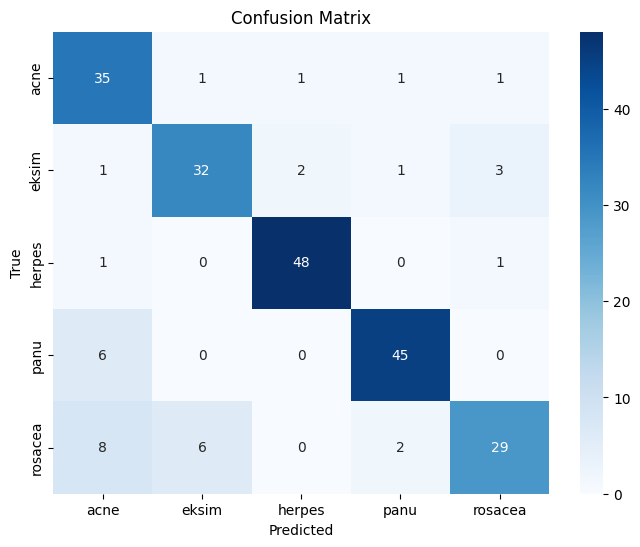

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

##Análise dos resultados

O modelo apresentou Macro F1 ≈ 0.84, indicando um desempenho geral razoável na classificação das doenças de pele. A acurácia total também ficou em 84%, mostrando que a maioria das imagens foi classificada corretamente.

Observando a matriz de confusão, nota-se que algumas classes foram aprendidas melhor que outras. A classe herpes apresentou o melhor desempenho (F1 ≈ 0.95), com poucos erros de classificação. Isso sugere que suas características visuais são mais distintas no dataset.

Por outro lado, a classe rosacea apresentou menor recall (0.64), sendo frequentemente confundida com acne e eksim. Isso pode ocorrer porque essas doenças possuem padrões visuais semelhantes, dificultando a distinção pelo modelo.

Também é possível observar que panu às vezes é classificado como acne, o que pode indicar semelhança em padrões de textura ou coloração nas imagens.

Outro ponto interessante é a diferença entre precision e recall em algumas classes. Por exemplo, acne apresenta recall alto (0.90) mas precision menor (0.69). Isso indica que o modelo consegue identificar a maioria das imagens de acne, mas também tende a classificar algumas imagens de outras doenças como acne.

Além disso, as métricas accuracy, macro F1 e weighted F1 apresentam valores muito próximos (≈ 0.84). Isso sugere que o conjunto de teste possui uma distribuição relativamente equilibrada entre as classes e que o desempenho do modelo não está sendo dominado por apenas uma classe.

Esses resultados sugerem que o modelo conseguiu aprender padrões relevantes, mas ainda encontra dificuldade em distinguir classes com características visuais parecidas. Além disso, embora o dataset seja relativamente equilibrado entre as classes (cerca de 300 imagens por categoria), o número total de imagens ainda é relativamente pequeno para treinar modelos de deep learning, o que pode limitar a capacidade do modelo de aprender representações mais robustas.

Melhorias possíveis incluem aumento do dataset, técnicas adicionais de data augmentation ou ajuste mais profundo do fine-tuning da rede.